# Phase 3 — evaluate the detector

Measures the trained detector on the **held-out test split**, which nothing has touched: validation drove early stopping and model selection, so validation numbers are mildly optimistic. This is the number that goes in the README.

Three outputs:

1. **Ultralytics mAP** on test — the standard metric.
2. **Slices by plate size** — an aggregate of 0.98 can hide 0.6 on plates under 32 px, and that is exactly the population Phase 4's OCR will fail on.
3. **A failure gallery** — the worst images with predictions drawn on them. Metrics say *that* something is wrong; only the images say what.

**Gate: mAP@50 ≥ 0.85 on test.** Below that, iterate on Phase 1 or 2 rather than pushing on — OCR can never read a plate the detector missed.

In [1]:
REPO = "https://github.com/fayazhussain2821/ALPR.git"
BRANCH = "main"

import os

if os.path.isdir("/content/ALPR"):
    !cd /content/ALPR && git fetch --quiet origin && git checkout --quiet $BRANCH && git pull --quiet
else:
    !git clone --quiet --branch $BRANCH $REPO /content/ALPR

%cd /content/ALPR
!pip install --quiet -e .

import sys

SRC = "/content/ALPR/src"
if SRC not in sys.path:
    sys.path.insert(0, SRC)

import alpr

print(f"alpr {alpr.__version__} importable")

/content/ALPR
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 40.5 MB/s eta 0:00:00
  Building editable for alpr (pyproject.toml) ... done
alpr 0.1.0 importable


## 0. Make sure the dataset exists

`ensure_dataset()` is a no-op when this session already has the data, and a full rebuild (download → manifest → split → export) when it does not. That makes this notebook runnable on its own in a fresh runtime — which matters, because free Colab allows one session and `/content` does not survive it.

In [3]:
pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.0/285.0 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 140.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 5.0.0.93
    Uninstalling opencv-python-headless-5.0.0.93:
      Successfully uninstalled opencv-python-headless-5.0.0.93
  Attempting uninstall: typer
    Found existing installation: typer 0.26.8
    Uninstalling typer-0.26.8:
      Successfully uninstalled typer-0.26.8


In [4]:
from alpr.build import ensure_dataset

# Rebuilds the dataset if this session does not already have it, and returns
# immediately if it does. Colab's free tier gives one GPU session and
# everything under /content dies with it, so a notebook that depends on a
# previous notebook's output usually cannot run at all.
#
# Needs ROBOFLOW_API_KEY in the 🔑 Secrets panel only when a download is
# actually required.
DATA = ensure_dataset()
print(f"dataset ready: {DATA}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to data/raw/roboflow-eu in yolov8:: 100%|██████████| 2922/2922 [00:00<00:00, 3429.88it/s]


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to data/raw/roboflow-in in yolov8:: 100%|██████████| 3312/3312 [00:00<00:00, 7443.49it/s]


dataset ready: data/yolo/data.yaml


## 1. Locate the weights

If you trained in this session, `best_weights` finds them. If the session was lost, upload the `best.pt` you downloaded and point `WEIGHTS` at it.

In [8]:
from pathlib import Path

from alpr.train import TrainConfig, best_weights

config = TrainConfig.from_yaml("configs/detector.yaml")

try:
    WEIGHTS = best_weights(config)
except Exception as exc:
    print(f"not found in this session ({exc})")
    print("Upload best.pt with the file browser, then set WEIGHTS manually.")
    WEIGHTS = Path("/content/best.pt")

print(f"weights: {WEIGHTS}  ({WEIGHTS.stat().st_size / 1e6:.1f} MB)")

not found in this session (no trained weights found under runs/detect — has training finished? (searched **/weights/best.pt))
Upload best.pt with the file browser, then set WEIGHTS manually.
weights: /content/best.pt  (22.5 MB)


## 2. Ultralytics mAP on the test split

`split="test"` is the important argument. The default is `val`, which would re-report the number training already optimized against.

In [9]:
from ultralytics import YOLO

model = YOLO(str(WEIGHTS))
metrics = model.val(data=str(DATA), split="test", imgsz=config.imgsz, verbose=False)

print(f"mAP@50      {metrics.box.map50:.4f}")
print(f"mAP@50-95   {metrics.box.map:.4f}")
print(f"precision   {metrics.box.mp:.4f}")
print(f"recall      {metrics.box.mr:.4f}")
print()
print("GATE: mAP@50 >= 0.85 —", "PASS" if metrics.box.map50 >= 0.85 else "FAIL")

Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 739.2±259.8 MB/s, size: 24.0 KB)
val: Scanning /content/ALPR/data/yolo/labels/test... 465 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 465/465 2.3Kit/s 0.2s
val: New cache created: /content/ALPR/data/yolo/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 30/30 3.4it/s 8.7s
                   all        465        483      0.982      0.992      0.992      0.838
Speed: 2.9ms preprocess, 8.6ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /content/ALPR/runs/detect/val
mAP@50      0.9921
mAP@50-95   0.8377
precision   0.9816
recall      0.9917

GATE: mAP@50 >= 0.85 — PASS


## 3. Run the detector over the test split

Predictions are needed for the size slices and the gallery, neither of which Ultralytics provides.

In [10]:
from alpr.data import Split, read_manifest, split_records
from alpr.detect import PlateDetector

records = read_manifest("data/manifest.jsonl")
assignment = split_records(records, seed=0)  # same seed as Phase 1
test_records = assignment.partition(records)[Split.TEST]
print(f"{len(test_records)} test images")

detector = PlateDetector(WEIGHTS, imgsz=config.imgsz)
print(f"device: {detector.device}")

RAW = Path("data/raw")
paths = [str(RAW / r.file_name) for r in test_records]

predictions = []
BATCH = 32
for start in range(0, len(paths), BATCH):
    predictions.extend(detector.detect_batch(paths[start : start + BATCH]))
    print(f"  {min(start + BATCH, len(paths))}/{len(paths)}", end="\r")

print(f"\n{sum(len(p) for p in predictions)} detections")

465 test images
device: 0
  465/465
505 detections


## 4. Sliced metrics

The row to watch is `tiny (<32px)`. If its recall is far below the rest, the ceiling on end-to-end accuracy is set by detection on small plates — and raising `imgsz` in Phase 2 is the fix, not more epochs.

In [11]:
from alpr.evaluate import evaluate_records

report = evaluate_records(test_records, predictions)
print(report.report())

IoU threshold      0.5
images             465
ground-truth       483
true positives     482
false positives    23
missed             1
precision          0.9545
recall             0.9979
f1                 0.9757

by plate width            n  precision   recall
tiny (<32px)              8     1.0000   1.0000
small (32-64px)          67     0.9041   0.9851
medium (64-128px)       204     0.9533   1.0000
large (>=128px)         204     0.9855   1.0000


## 5. Failure gallery

Green = correct, red = missed plate, orange = false positive.

20 failure image(s) written
01_3err_in-valid-319f51dc-9db2-4977-a43d-09561cdd54ab___1415806d1442489743t-raging-red-rover-r3-my-mahindra-scorpio-s10-4x4-nudge-guard-jpg_jpeg.rf.e22850f50adc85f9edb932a4a810520f.jpg


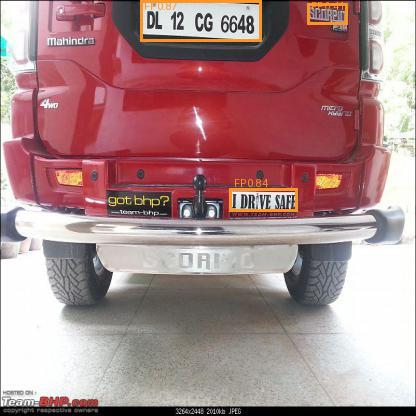

02_2err_eu-train-dayride_type1_001-mp4-t-1472_jpg.rf.d16f3d7d393c2618ffb6b8a1f5af0cc4.jpg


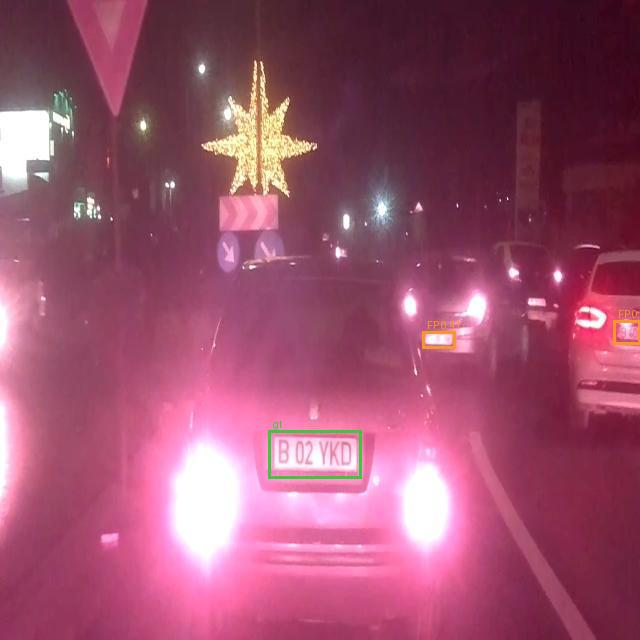

03_1err_eu-test-dayride_type1_001-mp4-t-491_jpg.rf.bca97daf1eb0a40df5a3ef85d6f03599.jpg


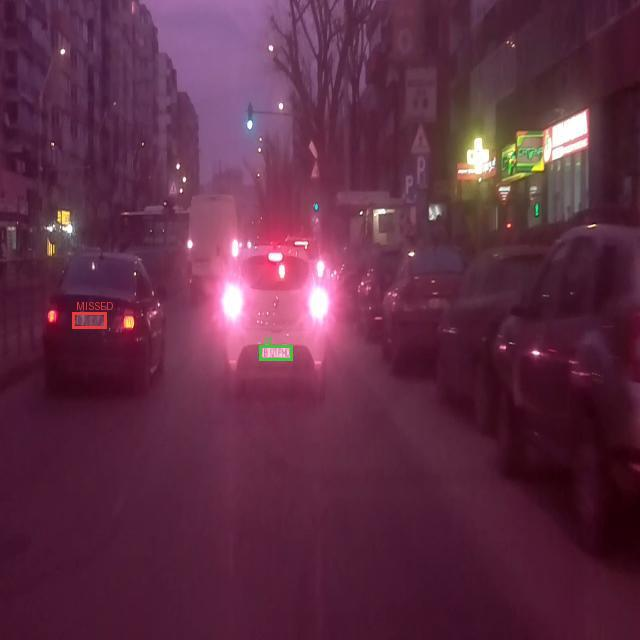

04_1err_eu-train-d_license_plate_204_jpg.rf.6cea85b29a9de13a3d42456d0248a5ee.jpg


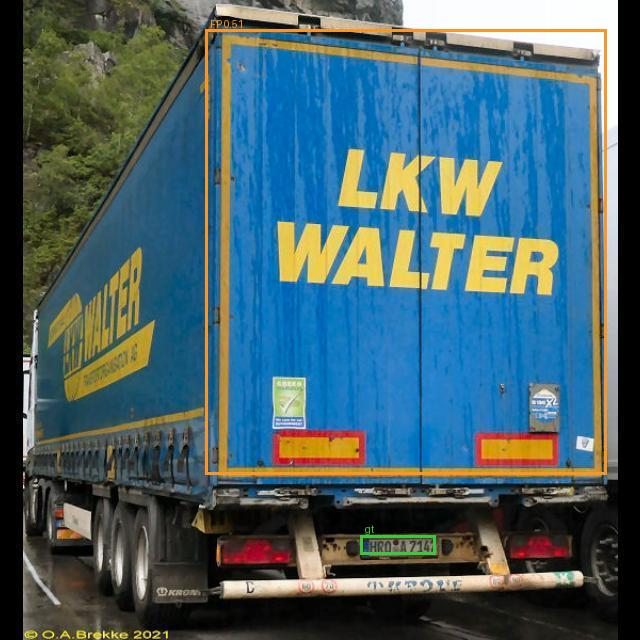

05_1err_eu-train-d_license_plate_455_jpg.rf.3a59e3177bb4a99141033dbc7107d75b.jpg


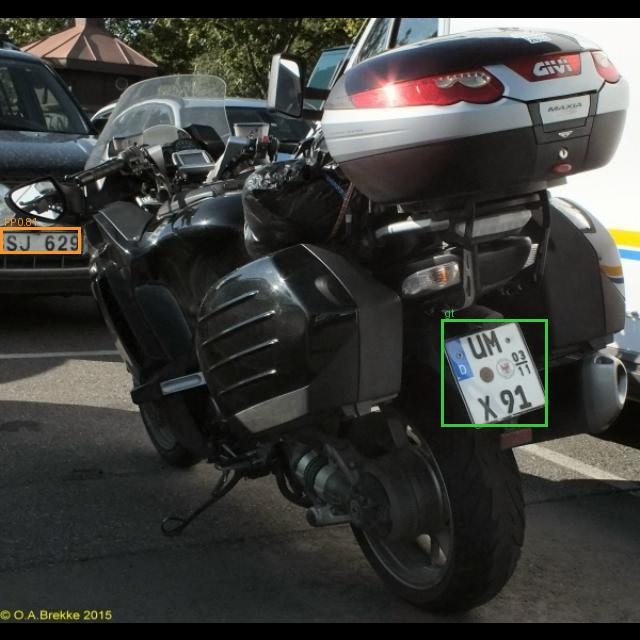

06_1err_eu-train-dayride_type1_001-mp4-t-1078_jpg.rf.196b9731687ad94aa9c30ce4967af2d0.jpg


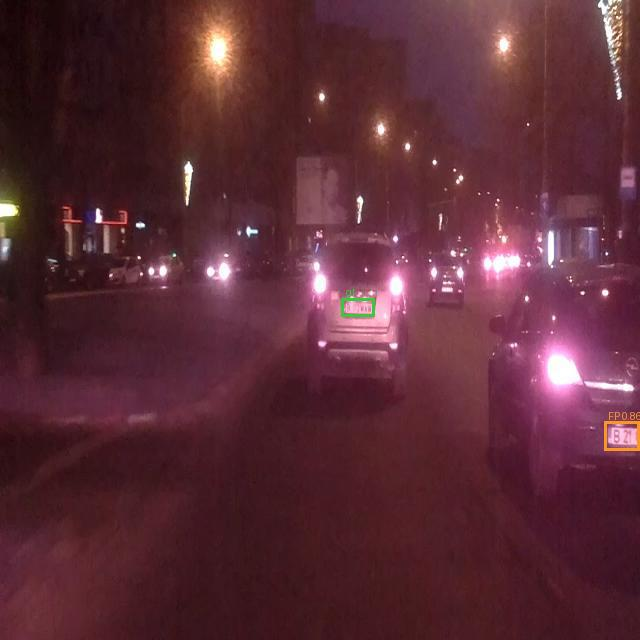

07_1err_eu-train-dayride_type1_001-mp4-t-1115_jpg.rf.0e19cdbaf4ebcd9807f9821253e88a63.jpg


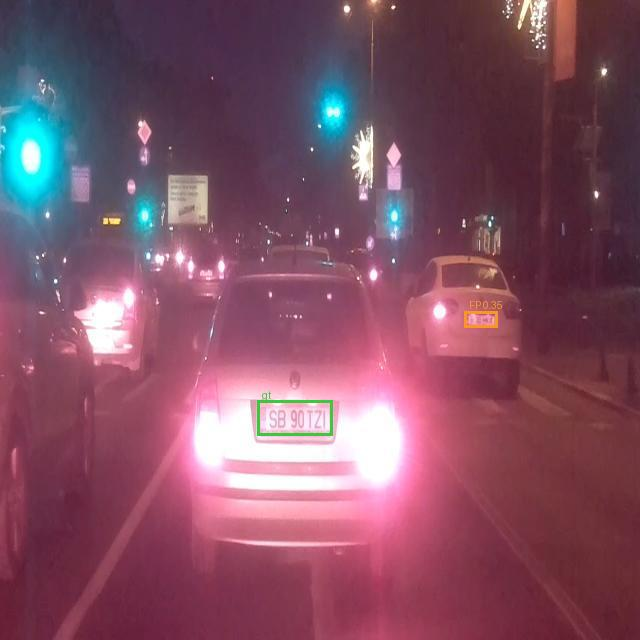

08_1err_eu-train-dayride_type1_001-mp4-t-1354_jpg.rf.bf364342118b98d97aa360d5e0ff9b77.jpg


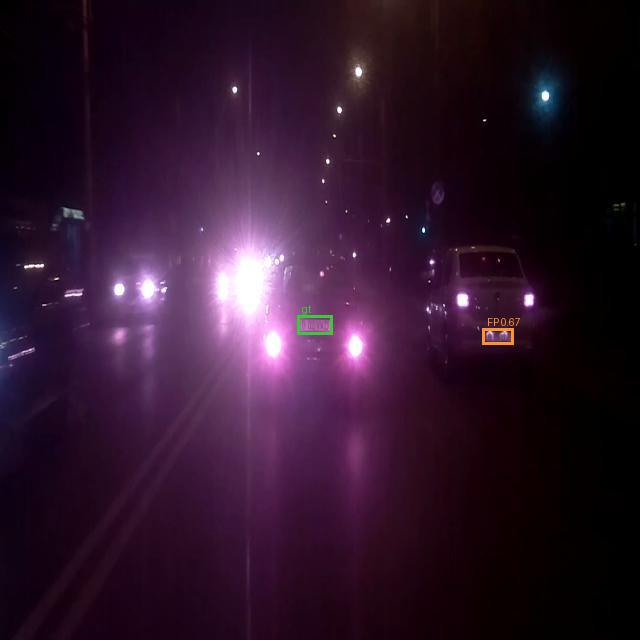

In [13]:
from IPython.display import Image as ShowImage
from IPython.display import display

from alpr.evaluate import render_failure_gallery

written = render_failure_gallery(
    report, test_records, predictions, RAW, "outputs/failures", limit=20
)
print(f"{len(written)} failure image(s) written")

for path in written[:8]:
    print(path.name)
    display(ShowImage(filename=str(path), width=300))

Look for a pattern rather than counting. Motion blur, night shots, plates at extreme angles and duplicate boxes on one plate all call for different fixes — more data, a different augmentation, or a lower NMS threshold. If the gallery is empty, there is nothing left to learn from failures at this IoU threshold.